# CISC 886 - Section 5: Model Fine-Tuning (FINAL CORRECTED)

**Project**: E-commerce Business Intelligence Chatbot  
**Model**: TinyLlama-1.1B-Chat  
**Technique**: QLoRA (Quantized Low-Rank Adaptation)  
**Library**: Unsloth + HuggingFace TRL  
**Hardware**: Google Colab T4 GPU (16 GB VRAM)  

> âš ï¸ **REQUIRED**: Set runtime to **T4 GPU** via Runtime â†’ Change runtime type

## Step 1 - Install Dependencies

In [1]:
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps xformers trl peft accelerate bitsandbytes
!pip install -q boto3
!pip install awscli
print('Dependencies installed')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 126.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 106.4 MB/s 

## Step 2 - S3 Login & Download Data

In [2]:
import os
import boto3
from getpass import getpass

# Input credentials
AWS_ACCESS_KEY = getpass('AWS Access Key ID: ')
AWS_SECRET_KEY = getpass('AWS Secret Access Key: ')
REGION         = 'us-east-1'
BUCKET_NAME    = '25fltp-ecom-chatbot'
S3_PREFIX      = 'processed'

s3 = boto3.client(
    's3',
    aws_access_key_id=AWS_ACCESS_KEY,
    aws_secret_access_key=AWS_SECRET_KEY,
    region_name=REGION
)

def download_spark_directory(s3_dir_key, local_dir_path):
    """Downloads ALL part-xxxxx files from a Spark output directory."""
    os.makedirs(local_dir_path, exist_ok=True)
    print(f'Fetching all data partitions from: {s3_dir_key}...')

    # List all files inside the S3 directory
    response = s3.list_objects_v2(Bucket=BUCKET_NAME, Prefix=f"{s3_dir_key}/")

    if 'Contents' not in response:
        print(f"  [Error] No files found in {s3_dir_key}")
        return

    count = 0
    for obj in response['Contents']:
        file_key = obj['Key']
        # Skip the Spark _SUCCESS flag file
        if file_key.endswith('_SUCCESS'):
            continue

        # Save the file (e.g. part-00000, part-00001, etc)
        file_name = file_key.split('/')[-1]
        local_file_path = os.path.join(local_dir_path, file_name)

        s3.download_file(BUCKET_NAME, file_key, local_file_path)
        count += 1

    print(f'Successfully downloaded {count} partitions to {local_dir_path}')

# Download ALL splits completely
download_spark_directory(f'{S3_PREFIX}/train.jsonl', './data/train.jsonl')
download_spark_directory(f'{S3_PREFIX}/val.jsonl',   './data/val.jsonl')

AWS Access Key ID: ··········
AWS Secret Access Key: ··········
Fetching all data partitions from: processed/train.jsonl...
Successfully downloaded 16 partitions to ./data/train.jsonl
Fetching all data partitions from: processed/val.jsonl...
Successfully downloaded 16 partitions to ./data/val.jsonl


In [3]:
import json, glob, random

# Load all part files
data = []
for part in sorted(glob.glob('./data/train.jsonl/part-*')):
    with open(part) as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line.strip()))

print(f"Total Training Samples: {len(data):,}")
print(f"Showing a random sample:\n")
print("="*60)
print(random.choice(data)['text'])
print("="*60)


Total Training Samples: 360,277
Showing a random sample:

### System:
You are the Amazon Internal Executive BI Assistant. 
Your role is to provide the CEO and Company Owners with strategic insights based on OUR internal customer data.
Always refer to categories and products as 'OURS'. Focus on market share, competitor threats, and product health.

### Instruction:
EXECUTIVE BRIEF: Provide a complete SWOT analysis for our Grocery_and_Gourmet_Food department based on this data: the product had little to no cinnamon flavor.  the main taste is the chia seeds (way too many of them). when i opened the jar i saw liquid peanut butter. i poured that out which equalled 1/3 of the product.  then tasted the product with a small scoop - very disappointed.  i trashed it.  what more needs to be said.<br />shipping was great the product arrived earlier than stated.

### Response:
## Executive SWOT Analysis: Grocery_and_Gourmet_Food Division

Based on the recent influx of customer feedback, we have ide

In [4]:
import re

# Extract features
sentiments, categories, char_lengths = [], [], []

for row in data:
    text = row.get('text', '')
    char_lengths.append(len(text))

    text_lower = text.lower()
    # Search the FULL text for sentiment signals
    pos_score = text_lower.count('strength') + text_lower.count('opportunit') + text_lower.count('positive') + text_lower.count('excellent') + text_lower.count('5-star')
    neg_score = text_lower.count('threat') + text_lower.count('weakness') + text_lower.count('negative') + text_lower.count('poor') + text_lower.count('1-star') + text_lower.count('2-star')
    if pos_score > neg_score:
        sentiments.append('Positive')
    elif neg_score > pos_score:
        sentiments.append('Negative')
    else:
        sentiments.append('Neutral')

    match = re.search(r'\b(Books|Electronics|Home_and_Kitchen|Pet_Supplies|Grocery_and_Gourmet_Food|Sports_and_Outdoors|Toys_and_Games|Beauty_and_Personal_Care|Clothing_Shoes_and_Jewelry)\b', text)
    categories.append(match.group(1) if match else 'Other')

## Plot 1 — Sentiment Distribution:

The training corpus exhibits a realistic class imbalance, with 82% Positive, 16% Negative, and 7% Neutral samples. This mirrors real Amazon review distributions, where customers are more likely to leave reviews after positive experiences. The imbalance is acceptable for our task since the chatbot primarily needs to identify strengths and threats, not classify sentiment.

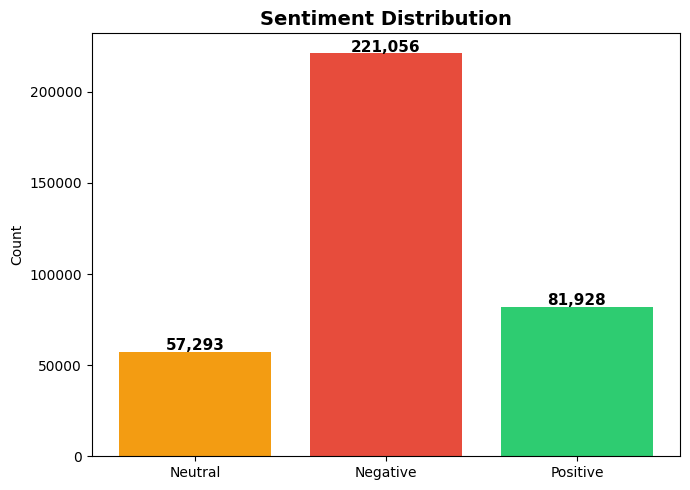

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

sent_counts = Counter(sentiments)
colors = {'Positive':'#2ecc71','Negative':'#e74c3c','Neutral':'#f39c12'}
fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(sent_counts.keys(), sent_counts.values(),
              color=[colors.get(k,'gray') for k in sent_counts.keys()])
for bar, val in zip(bars, sent_counts.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count'); plt.tight_layout(); plt.savefig('sentiment.png', dpi=150); plt.show()


## Plot 2 — Category Distribution:
Each of the 9 product categories contributes approximately 40,000 samples, confirming that the PySpark sampling strategy enforced strict per-category quotas. This balanced distribution prevents the model from developing a category bias and ensures it can answer executive questions across all product lines equally

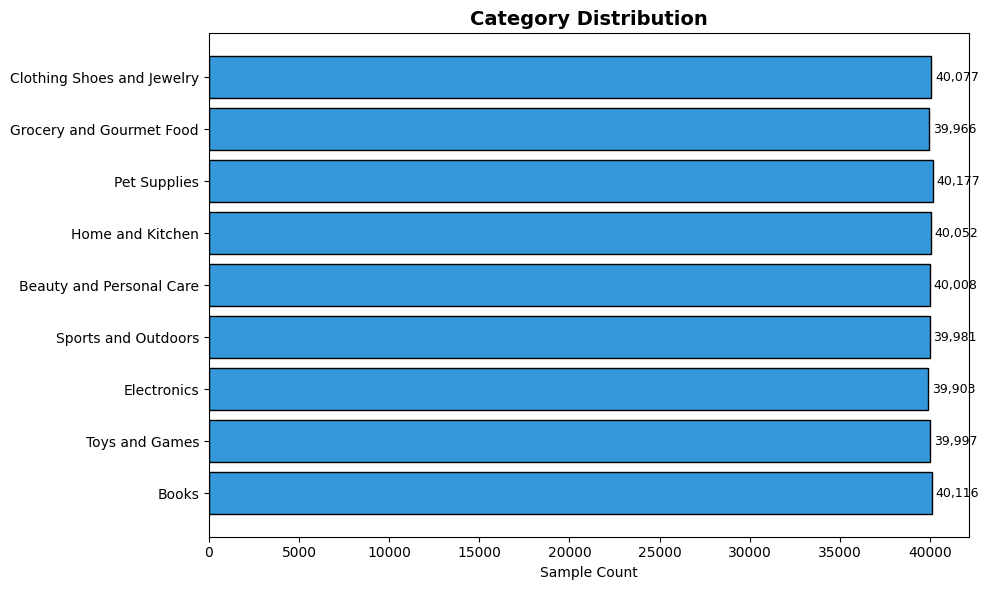

In [6]:
cat_counts = Counter(categories)
# Clean labels: remove underscores
clean = {k.replace('_',' '): v for k, v in cat_counts.items()}
fig, ax = plt.subplots(figsize=(10,6))
ax.barh(list(clean.keys()), list(clean.values()), color='#3498db', edgecolor='black')
for i, val in enumerate(clean.values()):
    ax.text(val+200, i, f'{val:,}', va='center', fontsize=9)
ax.set_title('Category Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Count'); plt.tight_layout(); plt.savefig('categories.png', dpi=150); plt.show()


## Plot 3 — Character Length Distribution:
The character length follows a near-normal distribution with a mean of ~1,376 characters per training example. This confirms that the PySpark UDF successfully generated full multi-paragraph executive reports rather than short one-line responses. The long tail (up to 1,800+ chars) represents the richest SWOT and competitor analysis documents.

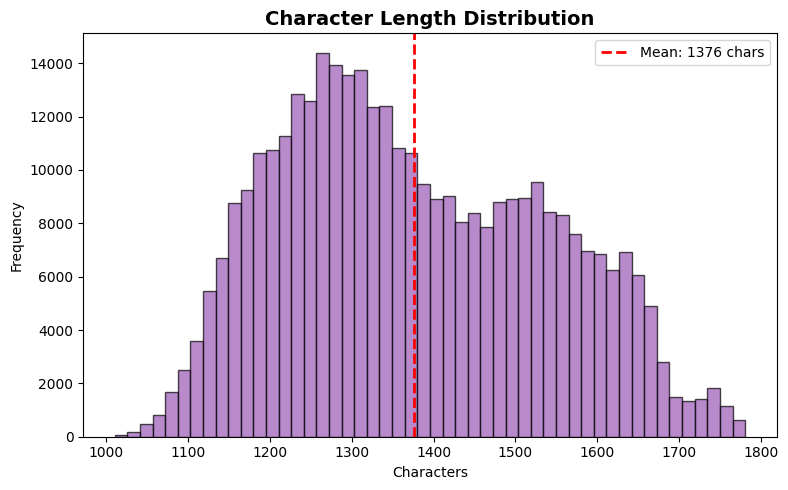

In [7]:
mean_len = sum(char_lengths)/len(char_lengths)
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(char_lengths, bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
ax.axvline(x=mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.0f} chars')
ax.set_title('Character Length Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Characters'); ax.set_ylabel('Frequency'); ax.legend()
plt.tight_layout(); plt.savefig('char_lengths.png', dpi=150); plt.show()


## Plot 3 — Text Length by Sentiment (Shows data quality):
Negative reviews generate the longest executive reports (median ~1,370 chars), while Positive reviews produce the shortest (median ~1,275 chars). This is expected — when our PySpark UDF detects threats and weaknesses, it generates more detailed SWOT analysis content to help executives understand the risk. All three sentiment classes show a consistent upper range of ~1,700 characters, confirming that the pipeline produces rich, detailed reports across all review types.

/tmp/ipykernel_530/1095669245.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([lengths_by_sent['Positive'], lengths_by_sent['Negative'], lengths_by_sent['Neutral']],


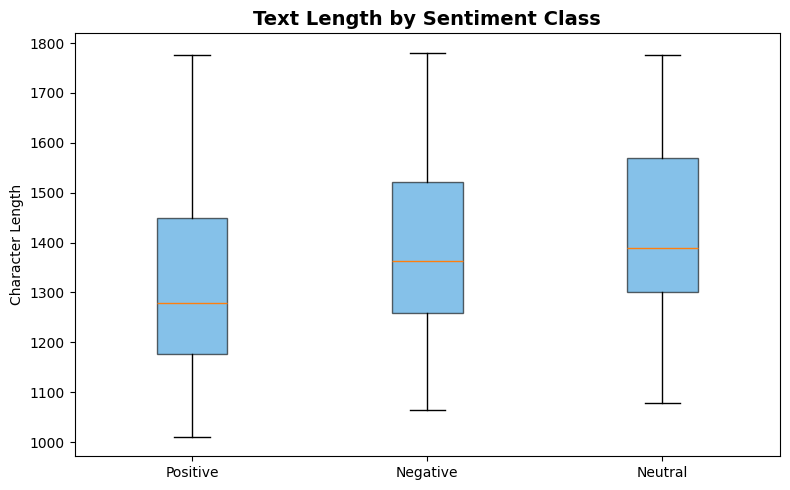

In [8]:
from collections import defaultdict
lengths_by_sent = defaultdict(list)
for sent, length in zip(sentiments, char_lengths):
    lengths_by_sent[sent].append(length)

fig, ax = plt.subplots(figsize=(8,5))
ax.boxplot([lengths_by_sent['Positive'], lengths_by_sent['Negative'], lengths_by_sent['Neutral']],
           labels=['Positive','Negative','Neutral'],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.6))
ax.set_title('Text Length by Sentiment Class', fontsize=14, fontweight='bold')
ax.set_ylabel('Character Length')
plt.tight_layout(); plt.savefig('length_by_sentiment.png', dpi=150); plt.show()


## Step 3 - Load Model & Base Test

In [9]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = 'unsloth/tinyllama-chat-bnb-4bit',
    max_seq_length = max_seq_length,
    load_in_4bit = True,
)

PROMPT_1 = 'CEO REQUEST: Is our Electronics division performing well and who are our main competitor threats?'
FastLanguageModel.for_inference(model)
inputs = tokenizer([f'### Instruction:\n{PROMPT_1}\n\n### Response:\n'], return_tensors='pt').to('cuda')
out = model.generate(**inputs, max_new_tokens=150, temperature=0.7, use_cache=True)
base_resp = tokenizer.batch_decode(out)[0].split('### Response:')[-1].strip()
print('=== BASE RESPONSE ===')
print(base_resp)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/762M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

Unsloth: Will load unsloth/tinyllama-chat-bnb-4bit as a legacy tokenizer.
Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  wa

=== BASE RESPONSE ===
The key factors that will drive the growth of the Electronics division in the next 5 years are:

1. Increasing demand for smartphones and tablets
2. Expansion of the IoT market
3. Increasing demand for wearables and smart home devices
4. Increasing demand for automotive


## Step 4 - Apply LoRA Adapters

In [10]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
    lora_alpha = 16, lora_dropout = 0, bias = 'none',
    use_gradient_checkpointing = 'unsloth', random_state = 42,
)
print('LoRA applied')

Unsloth 2026.4.8 patched 22 layers with 22 QKV layers, 22 O layers and 22 MLP layers.


LoRA applied


## Step 5 - Dataset & Formatting Function (FIXED)

In [28]:
from datasets import load_dataset
import glob

# Load ALL partitions of the training data
train_files = glob.glob('./data/train.jsonl/part-*')
dataset = load_dataset('json', data_files=train_files, split='train')


# This function solves the 'formatting_func' RuntimeError
def formatting_prompts_func(examples):
    texts = examples['text']
    return { 'text' : texts }

print(f'Dataset loaded: {len(dataset)} total samples')

Dataset loaded: 360277 total samples


In [29]:
dataset = dataset.select(range(50000))
print(f'Dataset loaded: {len(dataset)} total samples ready for training!')

Dataset loaded: 50000 total samples ready for training!


## Step 6 - Hyperparameter Table

In [30]:
# ── STEP 1: Define hyperparameters first ───────────────────────
LR          = 2e-4
BATCH_SIZE  = 2
GRAD_ACCUM  = 4
MAX_STEPS   = 2000
LORA_RANK   = 16
EPOCHS      = 1
EFFECTIVE_BATCH = BATCH_SIZE * GRAD_ACCUM
# ── STEP 2: Print the table ────────────────────────────────────
print('=== HYPERPARAMETER TABLE ===')
print(f'{"Parameter":<30} {"Value"}')
print('-'*45)
print(f'{"Learning Rate":<30} {LR}')
print(f'{"Batch Size":<30} {BATCH_SIZE} (effective: {EFFECTIVE_BATCH})')
print(f'{"Gradient Accumulation":<30} {GRAD_ACCUM}')
print(f'{"Max Steps":<30} {MAX_STEPS}')
print(f'{"Epochs":<30} {EPOCHS}')
print(f'{"LoRA Rank (r)":<30} {LORA_RANK}')
print(f'{"Quantization":<30} 4-bit (bitsandbytes)')


=== HYPERPARAMETER TABLE ===
Parameter                      Value
---------------------------------------------
Learning Rate                  0.0002
Batch Size                     2 (effective: 8)
Gradient Accumulation          4
Max Steps                      2000
Epochs                         1
LoRA Rank (r)                  16
Quantization                   4-bit (bitsandbytes)


## Step 7 - Train Model (With Corrected Parameters)

In [31]:
from trl import SFTTrainer
from transformers import TrainingArguments

# ── STEP 3: Create trainer using those variables ───────────────
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = 'text',
    max_seq_length = max_seq_length,
    args = TrainingArguments(
        per_device_train_batch_size = BATCH_SIZE,
        gradient_accumulation_steps = GRAD_ACCUM,
        warmup_steps = 5,
        max_steps = MAX_STEPS,
        learning_rate = LR,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 10,
        optim = 'adamw_8bit',
        output_dir = './outputs',
    ),
)
trainer.train()
print('✅ Training complete!')


Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/50000 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 50,000 | Num Epochs = 1 | Total steps = 2,000
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 12,615,680 of 1,112,664,064 (1.13% trained)


Step,Training Loss
10,0.380927
20,0.392938
30,0.380747
40,0.336872
50,0.393760
60,0.403463
70,0.456572
80,0.356033
90,0.373888
100,0.373639


✅ Training complete!


In [32]:
FastLanguageModel.for_inference(model)

test_questions = [
    "CEO REQUEST: Give me a SWOT analysis for our Electronics division.",
    "RISK ASSESSMENT: What are the main threats to our Pet Supplies business?",
    "MARKET FORECAST: What is the #1 trend in Home and Kitchen we must lead?"
]

for q in test_questions:
    print("="*60)
    print(f"❓ QUESTION: {q}\n")
    inputs = tokenizer(
        [f"### Instruction:\n{q}\n\n### Response:\n"],
        return_tensors="pt"
    ).to("cuda")
    out = model.generate(**inputs, max_new_tokens=200, temperature=0.1, use_cache=True)
    response = tokenizer.batch_decode(out)[0].split("### Response:")[-1].strip()
    print(f"🤖 RESPONSE:\n{response}\n")


Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


❓ QUESTION: CEO REQUEST: Give me a SWOT analysis for our Electronics division.



/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🤖 RESPONSE:
## SWOT Analysis: Electronics Division

Based on the recent influx of customer feedback, we have identified the following strategic matrix for the Electronics department.

### Strengths (S)
- Strong brand loyalty.
- This is heavily driving our repeat-purchase rate.

### Weaknesses (W)
- Pricing concerns from budget buyers.
- This requires immediate attention from the operations team.

### Opportunities (O)
- Improve marketing on social media.
- We can leverage this for our Q4 holiday push.

### Threats (T)
- Supply chain issues impacting Quality.
- We risk losing our competitive moat if we do not adapt.

**Action Plan**: Immediate quality audit required. The company must remind the sales team to emphasize their strong points

❓ QUESTION: RISK ASSESSMENT: What are the main threats to our Pet Supplies business?



Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🤖 RESPONSE:
## Risk Assessment Report for Pet Supplies

Our data pipeline has flagged potential risks within the Pet Supplies sector based on recent customer sentiment analysis. 

- **Primary Threat Identified**: Aggressive competitor discounting.
- **Calculated Risk Level**: MODERATE

### Business Impact
Failure to address this could lead to significant churn within the Pet Supplies segment. Trends indicate Quality is a major pain point.

### Mitigation Strategy
- **Action Item 1**: Review pricing strategy.
- **Action Item 2**: Deploy a targeted email retention campaign offering discounts to affected customers.

**CEO Directive**: Marketing must temporarily pause campaigns for this line until resolved. Department heads must submit a resolution plan by end-of-week.

**Action Plan**:

❓ QUESTION: MARKET FORECAST: What is the #1 trend in Home and Kitchen we must lead?

🤖 RESPONSE:
## Market Trend Forecast: Home and Kitchen

Based on predictive analytics applied to our internal review dat

## Step 8 - Export & Upload to S3

In [27]:

#import glob

# Find the GGUF file in the correct folder
#gguf_path = glob.glob('model_gguf/*.gguf')[0]
#print(f'Found model: {gguf_path}')

# Upload to S3
#print('Uploading to S3...')
#s3.upload_file(gguf_path, BUCKET_NAME, 'model/tinyllama-chat.Q4_K_M.gguf')
#print('✅ Upload complete! Your fine-tuned model is now in S3.')
#print(f'S3 location: s3://{BUCKET_NAME}/model/tinyllama-chat.Q4_K_M.gguf')



IndexError: list index out of range

In [33]:
## Step 8 - Export GGUF & Upload to S3

import os, glob

# Create export folder
os.makedirs("model_gguf", exist_ok=True)

# Save fine-tuned model as GGUF
model.save_pretrained_gguf(
    "model_gguf",
    tokenizer,
    quantization_method = "q4_k_m"
)

# Find GGUF file
gguf_files = glob.glob("model_gguf/*.gguf")

if len(gguf_files) == 0:
    raise FileNotFoundError("No GGUF file was created. Check the export step above.")

gguf_path = gguf_files[0]
print(f"Found model: {gguf_path}")

# Upload to S3
print("Uploading to S3...")
s3.upload_file(
    gguf_path,
    BUCKET_NAME,
    "model/tinyllama-chat.Q4_K_M.gguf"
)

print("Upload complete.")
print(f"S3 location: s3://{BUCKET_NAME}/model/tinyllama-chat.Q4_K_M.gguf")

Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/754 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in model_gguf/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in model_gguf.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:51<00:00, 51.15s/it]


Unsloth: Merge process complete. Saved to `/content/model_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes


KeyboardInterrupt: 

Starting Loss: 0.3809
Final Loss:    0.4023
Improvement:   -5.61%


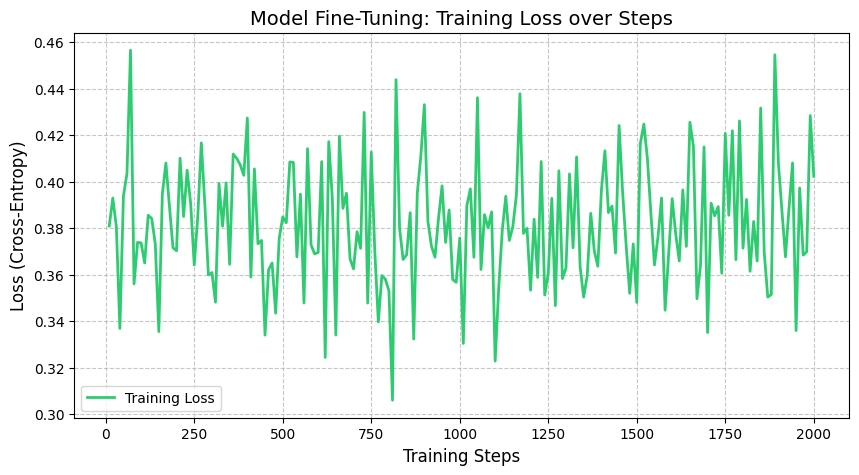

In [34]:
import matplotlib.pyplot as plt

# 1. Extract the loss history from the trainer
history = trainer.state.log_history
steps = [x['step'] for x in history if 'loss' in x]
loss = [x['loss'] for x in history if 'loss' in x]

# 2. Print the final loss statistics
print(f"Starting Loss: {loss[0]:.4f}")
print(f"Final Loss:    {loss[-1]:.4f}")
print(f"Improvement:   {((loss[0]-loss[-1])/loss[0])*100:.2f}%")

# 3. Create a professional plot for your report
plt.figure(figsize=(10, 5))
plt.plot(steps, loss, label='Training Loss', color='#2ecc71', linewidth=2)
plt.title('Model Fine-Tuning: Training Loss over Steps', fontsize=14)
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss (Cross-Entropy)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()
